In [1]:
import pandas as pd
import os
import logging
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [2]:
#Configure logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

In [3]:
#Ensure NLTK stopwords are available
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/hachikaruanyakwee/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
#Define file paths
sentiment_dir = os.path.join("..", "data", "sentiment")
output_file_pos = os.path.join(sentiment_dir, "positive_words_analysis.csv")
output_file_neg = os.path.join(sentiment_dir, "negative_words_analysis.csv")

In [5]:
#Load dataset
logging.info(f"Loading sentiment analysis results from: {os.path.join(sentiment_dir, 'sentiment_analysis.csv')}")
df = pd.read_csv(os.path.join(sentiment_dir, "sentiment_analysis.csv"))

2025-03-24 00:06:16,087 - INFO - Loading sentiment analysis results from: ../data/sentiment/sentiment_analysis.csv


In [6]:
#Ensure required columns exist
if "final_sentiment" not in df.columns or "text" not in df.columns:
    raise ValueError("Missing required columns ('final_sentiment' and 'text') in sentiment dataset!")

In [7]:
#Filter positive and negative comments
positive_df = df[df["final_sentiment"] == "Positive"]
negative_df = df[df["final_sentiment"] == "Negative"]
logging.info(f"Found {len(positive_df)} positive comments and {len(negative_df)} negative comments.")

2025-03-24 00:06:16,127 - INFO - Found 442 positive comments and 449 negative comments.


In [8]:
#Combine all text for each sentiment category
positive_text = " ".join(positive_df["text"].dropna())
negative_text = " ".join(negative_df["text"].dropna())

In [9]:
#Tokenization & Stopword Removal
stop_words = set(stopwords.words("english"))
positive_words = word_tokenize(positive_text)
positive_words = [word.lower() for word in positive_words if word.isalnum() and word.lower() not in stop_words]

negative_words = word_tokenize(negative_text)
negative_words = [word.lower() for word in negative_words if word.isalnum() and word.lower() not in stop_words]

In [10]:
#Word Frequency Analysis
positive_counts = Counter(positive_words)
negative_counts = Counter(negative_words)

common_positive = positive_counts.most_common(50)
common_negative = negative_counts.most_common(50)

df_common_positive = pd.DataFrame(common_positive, columns=["Word", "Frequency"])
df_common_negative = pd.DataFrame(common_negative, columns=["Word", "Frequency"])

df_common_positive.to_csv(output_file_pos, index=False)
df_common_negative.to_csv(output_file_neg, index=False)

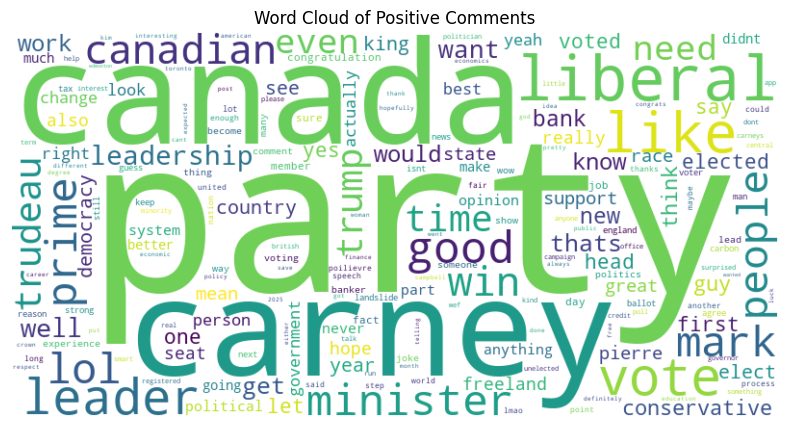

2025-03-24 00:06:16,739 - INFO - ✅ Word cloud for positive comments saved!


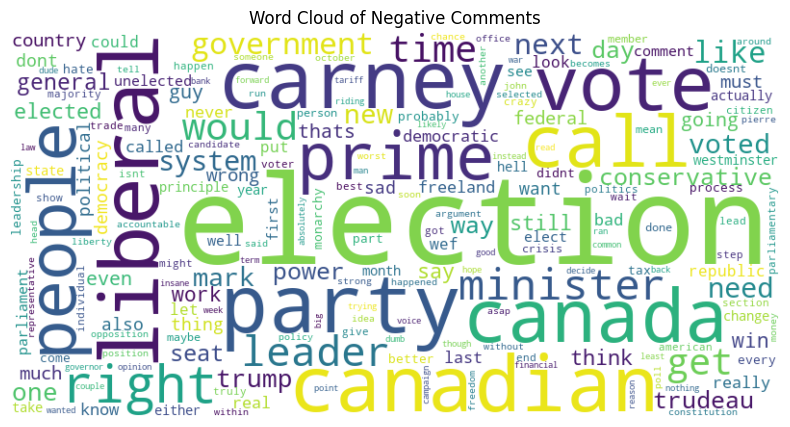

2025-03-24 00:06:17,269 - INFO - ✅ Word cloud for negative comments saved!


In [11]:
#Generate Word Clouds
wordcloud_positive = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(positive_counts)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positive, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Positive Comments")
plt.savefig(os.path.join(sentiment_dir, "positive_wordcloud.png"))
plt.show()
plt.close()
logging.info("✅ Word cloud for positive comments saved!")

wordcloud_negative = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(negative_counts)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negative, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Negative Comments")
plt.savefig(os.path.join(sentiment_dir, "negative_wordcloud.png"))
plt.show()
plt.close()
logging.info("✅ Word cloud for negative comments saved!")

/var/folders/wc/lj0_3jjn1zv0_y7s7thm5jqw0000gn/T/ipykernel_80532/3557099527.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_common_positive["Frequency"][:20], y=df_common_positive["Word"][:20], palette="coolwarm")


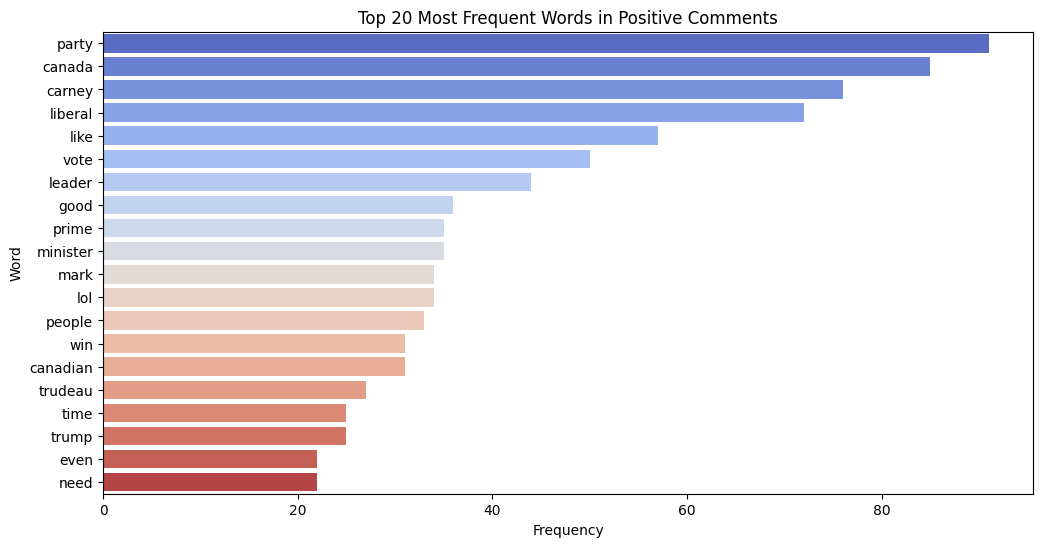

2025-03-24 00:06:17,548 - INFO - 📊 Positive sentiment word frequency plot saved!
/var/folders/wc/lj0_3jjn1zv0_y7s7thm5jqw0000gn/T/ipykernel_80532/3557099527.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_common_negative["Frequency"][:20], y=df_common_negative["Word"][:20], palette="coolwarm")


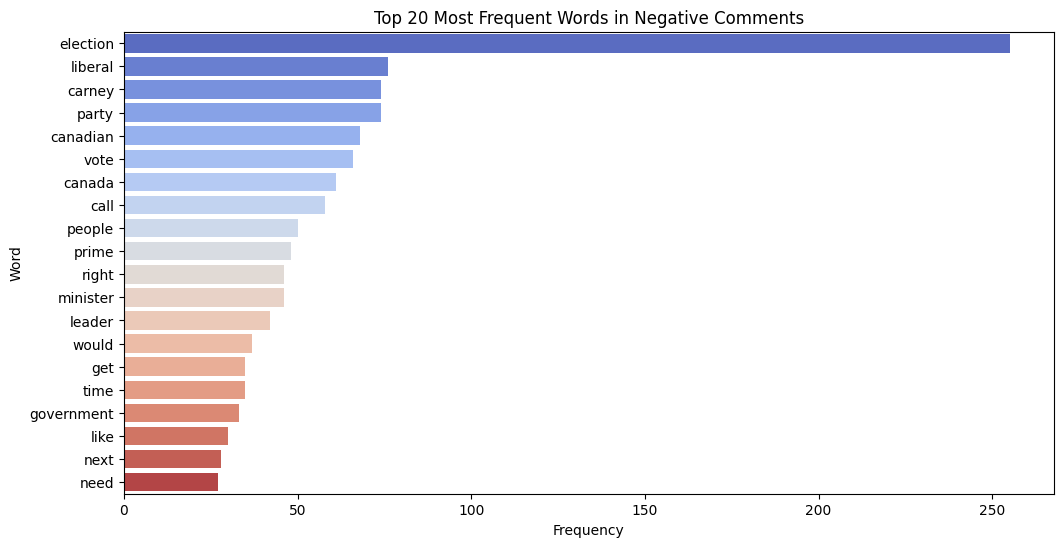

2025-03-24 00:06:17,826 - INFO - 📊 Negative sentiment word frequency plot saved!
2025-03-24 00:06:17,826 - INFO - ✅ Sentiment keyword analysis complete!


In [12]:
#Plot Top 20 Common Words in Each Category
plt.figure(figsize=(12, 6))
sns.barplot(x=df_common_positive["Frequency"][:20], y=df_common_positive["Word"][:20], palette="coolwarm")
plt.title("Top 20 Most Frequent Words in Positive Comments")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.savefig(os.path.join(sentiment_dir, "positive_word_frequency.png"))
plt.show()
plt.close()
logging.info("📊 Positive sentiment word frequency plot saved!")

plt.figure(figsize=(12, 6))
sns.barplot(x=df_common_negative["Frequency"][:20], y=df_common_negative["Word"][:20], palette="coolwarm")
plt.title("Top 20 Most Frequent Words in Negative Comments")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.savefig(os.path.join(sentiment_dir, "negative_word_frequency.png"))
plt.show()
plt.close()
logging.info("📊 Negative sentiment word frequency plot saved!")

logging.info("✅ Sentiment keyword analysis complete!")